In [1]:
ROLL_NUMBER=307   #24UG00307
SEAT_NUMBER=22
METHOD_PREFIX="Gamma"

In [2]:
print("="*70)
print("ZOO ANIMAL CLASSIFICATION - LAB EXAM")
print("="*70)
print(f"Roll Number: {ROLL_NUMBER}")
print(f"Seat Number: {SEAT_NUMBER}")
print(f"Method Number: {METHOD_PREFIX}")
print("="*70)

ZOO ANIMAL CLASSIFICATION - LAB EXAM
Roll Number: 307
Seat Number: 22
Method Number: Gamma


In [119]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
#TASK 1:DATA LOADING AND INTEGRATION

In [13]:
#A.Load All Three Datasets
#==================================================================
zoo_df=pd.read_csv("zoo.csv")
class_df=pd.read_csv("class.csv")
with open("auxiliary_metadata.json", "r") as file:
    metadata=json.load(file)
meta_df=pd.DataFrame(metadata)

In [11]:
#B. Apply Name Normalization(6-7)
# Keep Original case, handle duplicates case-insensentively
zoo_df = zoo_df.drop_duplicates()

In [43]:
#C. Fix JSON Data Inconsistentencies
#=====================================================================================================================================================
#Standarizination of column names
meta_df = meta_df.rename(columns={"conservation": "conservation_status", "status": "conservation_status", "habitats": "habitat", "diet_type": "diet"})

#removing duplicate columns
if "conservation_status" in meta_df.columns:
    meta_df["conservation_status"] = meta_df["conservation_status"].fillna(method="bfill")

if "habitat" in meta_df.columns:
    meta_df["habitat"] = meta_df["habitat"].fillna(method="bfill")

if "diet" in meta_df.columns:
    meta_df["diet"] = meta_df["diet"].fillna(method="bfill")

meta_df = meta_df.loc[:, ~meta_df.columns.duplicated()]

#Typo Fixing
meta_df["diet"] = meta_df["diet"].str.lower().str.strip()
meta_df["habitat"] = meta_df["habitat"].str.lower().str.strip()
meta_df["diet"] = meta_df["diet"].replace({"omnivor": "omnivore"})
meta_df["habitat"] = meta_df["habitat"].replace({"grasslands": "grassland"})

C:\Users\ub14-glab-007\AppData\Local\Temp\ipykernel_7268\3445803692.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  meta_df["conservation_status"] = meta_df["conservation_status"].fillna(method="bfill")
C:\Users\ub14-glab-007\AppData\Local\Temp\ipykernel_7268\3445803692.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  meta_df["habitat"] = meta_df["habitat"].fillna(method="bfill")
C:\Users\ub14-glab-007\AppData\Local\Temp\ipykernel_7268\3445803692.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  meta_df["diet"] = meta_df["diet"].fillna(method="bfill")


In [44]:
meta_df

,animal_name,habitat,diet,conservation_status
0,aardvark,savanna,insectivore,least concern
1,antelope,grassland,herbivore,least
2,bass,freshwater,carnivore,least
3,bear,forest,omnivore,vulnerable
4,boar,forest,omnivore,least concern
5,buffalo,grassland,herbivore,least concern
6,calf,domestic,herbivore,least concern
7,carp,fresh water,omnivore,least concern
8,catfish,freshwater,carnivore,least concern
9,clam,marine,filter_feeder,least concern


In [67]:
#D. Merge all Data SETS
class_df.columns = class_df.columns.str.lower()
class_df.rename(columns={'animal_names': 'animal_name'}, inplace=True)
class_df

,class_number,number_of_animal_species_in_class,class_type,animal_name
0,1,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,..."
1,2,20,Bird,"chicken, crow, dove, duck, flamingo, gull, haw..."
2,3,5,Reptile,"pitviper, seasnake, slowworm, tortoise, tuatara"
3,4,13,Fish,"bass, carp, catfish, chub, dogfish, haddock, h..."
4,5,4,Amphibian,"frog, frog, newt, toad"
5,6,8,Bug,"flea, gnat, honeybee, housefly, ladybird, moth..."
6,7,10,Invertebrate,"clam, crab, crayfish, lobster, octopus, scorpi..."


In [68]:
zoo_class_df = pd.merge(zoo_df, class_df, on="animal_name", how="left")
zoo_class_df.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,...,venomous,fins,legs,tail,domestic,catsize,class_type_x,class_number,number_of_animal_species_in_class,class_type_y
0,aardvark,1,0,0,1,0,0,1,1,1,...,0,0,4,0,0,1,1,NaN,NaN,NaN
1,antelope,1,0,0,1,0,0,0,1,1,...,0,0,4,1,0,1,1,NaN,NaN,NaN
2,bass,0,0,1,0,0,1,1,1,1,...,0,1,0,1,0,0,4,NaN,NaN,NaN
3,bear,1,0,0,1,0,0,1,1,1,...,0,0,4,0,0,1,1,NaN,NaN,NaN
4,boar,1,0,0,1,0,0,1,1,1,...,0,0,4,1,0,1,1,NaN,NaN,NaN


In [86]:
final_df = pd.merge(zoo_class_df, meta_df, on="animal_name", how="left")

In [87]:
merge_df=final_df.drop(["class_number", "number_of_animal_species_in_class", "class_type_y"], axis=1)

In [88]:
merge_df

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,...,venomous,fins,legs,tail,domestic,catsize,class_type_x,habitat,diet,conservation_status
0,aardvark,1,0,0,1,0,0,1,1,1,...,0,0,4,0,0,1,1,savanna,insectivore,least concern
1,antelope,1,0,0,1,0,0,0,1,1,...,0,0,4,1,0,1,1,grassland,herbivore,least
2,bass,0,0,1,0,0,1,1,1,1,...,0,1,0,1,0,0,4,freshwater,carnivore,least
3,bear,1,0,0,1,0,0,1,1,1,...,0,0,4,0,0,1,1,forest,omnivore,vulnerable
4,boar,1,0,0,1,0,0,1,1,1,...,0,0,4,1,0,1,1,forest,omnivore,least concern
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,...,0,0,2,1,0,1,1,NaN,NaN,NaN
97,wasp,1,0,1,0,1,0,0,0,0,...,1,0,6,0,0,0,6,NaN,NaN,NaN
98,wolf,1,0,0,1,0,0,1,1,1,...,0,0,4,1,0,1,1,NaN,NaN,NaN
99,worm,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,7,NaN,NaN,NaN


In [92]:
#E. Handle Missing Values
merge_df["diet"] = merge_df["diet"].fillna("Unknown")
merge_df["habitat"] = merge_df["habitat"].fillna("Unknown")
merge_df["conservation_status"] = merge_df["conservation_status"].fillna("Unknown")

In [93]:
merge_df

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,...,venomous,fins,legs,tail,domestic,catsize,class_type_x,habitat,diet,conservation_status
0,aardvark,1,0,0,1,0,0,1,1,1,...,0,0,4,0,0,1,1,savanna,insectivore,least concern
1,antelope,1,0,0,1,0,0,0,1,1,...,0,0,4,1,0,1,1,grassland,herbivore,least
2,bass,0,0,1,0,0,1,1,1,1,...,0,1,0,1,0,0,4,freshwater,carnivore,least
3,bear,1,0,0,1,0,0,1,1,1,...,0,0,4,0,0,1,1,forest,omnivore,vulnerable
4,boar,1,0,0,1,0,0,1,1,1,...,0,0,4,1,0,1,1,forest,omnivore,least concern
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,...,0,0,2,1,0,1,1,Unknown,Unknown,Unknown
97,wasp,1,0,1,0,1,0,0,0,0,...,1,0,6,0,0,0,6,Unknown,Unknown,Unknown
98,wolf,1,0,0,1,0,0,1,1,1,...,0,0,4,1,0,1,1,Unknown,Unknown,Unknown
99,worm,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,7,Unknown,Unknown,Unknown


In [96]:
#Feature Enigineering
merge_df["conservation_priority"] = 0 

merge_df.loc[merge_df["conservation_status"].str.lower() == "least concern", "conservation_priority"] = 1
merge_df.loc[merge_df["conservation_status"].str.lower() == "near threatened", "conservation_priority"] = 3
merge_df.loc[merge_df["conservation_status"].str.lower() == "vulnerable", "conservation_priority"] = 4
merge_df.loc[merge_df["conservation_status"].str.lower() == "endangered", "conservation_priority"] = 5

In [97]:
merge_df["aquatic_flag"] = 0

merge_df.loc[merge_df["habitat"].str.contains("water", case=False), "aquatic_flag"] = 1


In [98]:
merge_df

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,...,legs,tail,domestic,catsize,class_type_x,habitat,diet,conservation_status,conservation_priority,aquatic_flag
0,aardvark,1,0,0,1,0,0,1,1,1,...,4,0,0,1,1,savanna,insectivore,least concern,1,0
1,antelope,1,0,0,1,0,0,0,1,1,...,4,1,0,1,1,grassland,herbivore,least,0,0
2,bass,0,0,1,0,0,1,1,1,1,...,0,1,0,0,4,freshwater,carnivore,least,0,1
3,bear,1,0,0,1,0,0,1,1,1,...,4,0,0,1,1,forest,omnivore,vulnerable,4,0
4,boar,1,0,0,1,0,0,1,1,1,...,4,1,0,1,1,forest,omnivore,least concern,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,...,2,1,0,1,1,Unknown,Unknown,Unknown,0,0
97,wasp,1,0,1,0,1,0,0,0,0,...,6,0,0,0,6,Unknown,Unknown,Unknown,0,0
98,wolf,1,0,0,1,0,0,1,1,1,...,4,1,0,1,1,Unknown,Unknown,Unknown,0,0
99,worm,0,0,1,0,0,0,0,0,0,...,0,0,0,0,7,Unknown,Unknown,Unknown,0,0


In [101]:
#TASK 2 EDA
#Create 4 Visualsations

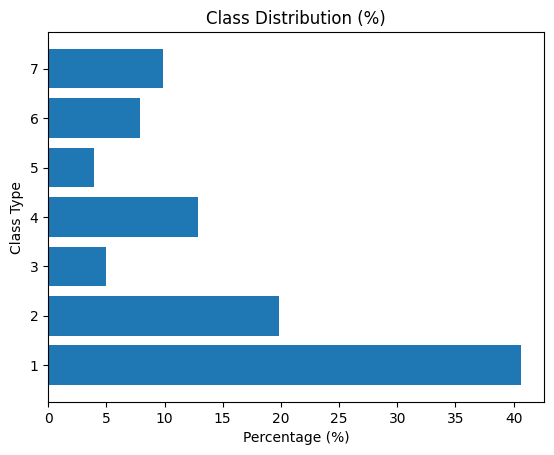

In [105]:
#1. horizontal bar charts class distribution with percentage
counts = merge_df["class_type_x"].value_counts()
percent = (counts / len(merge_df)) * 100

plt.barh(counts.index, percent)
plt.xlabel("Percentage (%)")
plt.ylabel("Class Type")
plt.title("Class Distribution (%)")

plt.show()

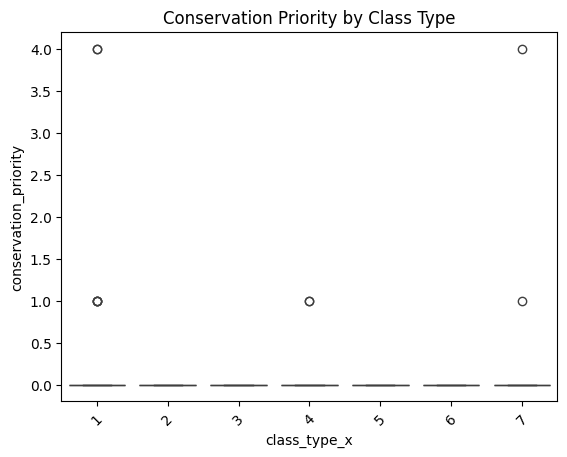

In [108]:
#2.box plot engineered features vs classes 
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="class_type_x", y="conservation_priority", data=merge_df)
plt.xticks(rotation=45)
plt.title("Conservation Priority by Class Type")
plt.show()


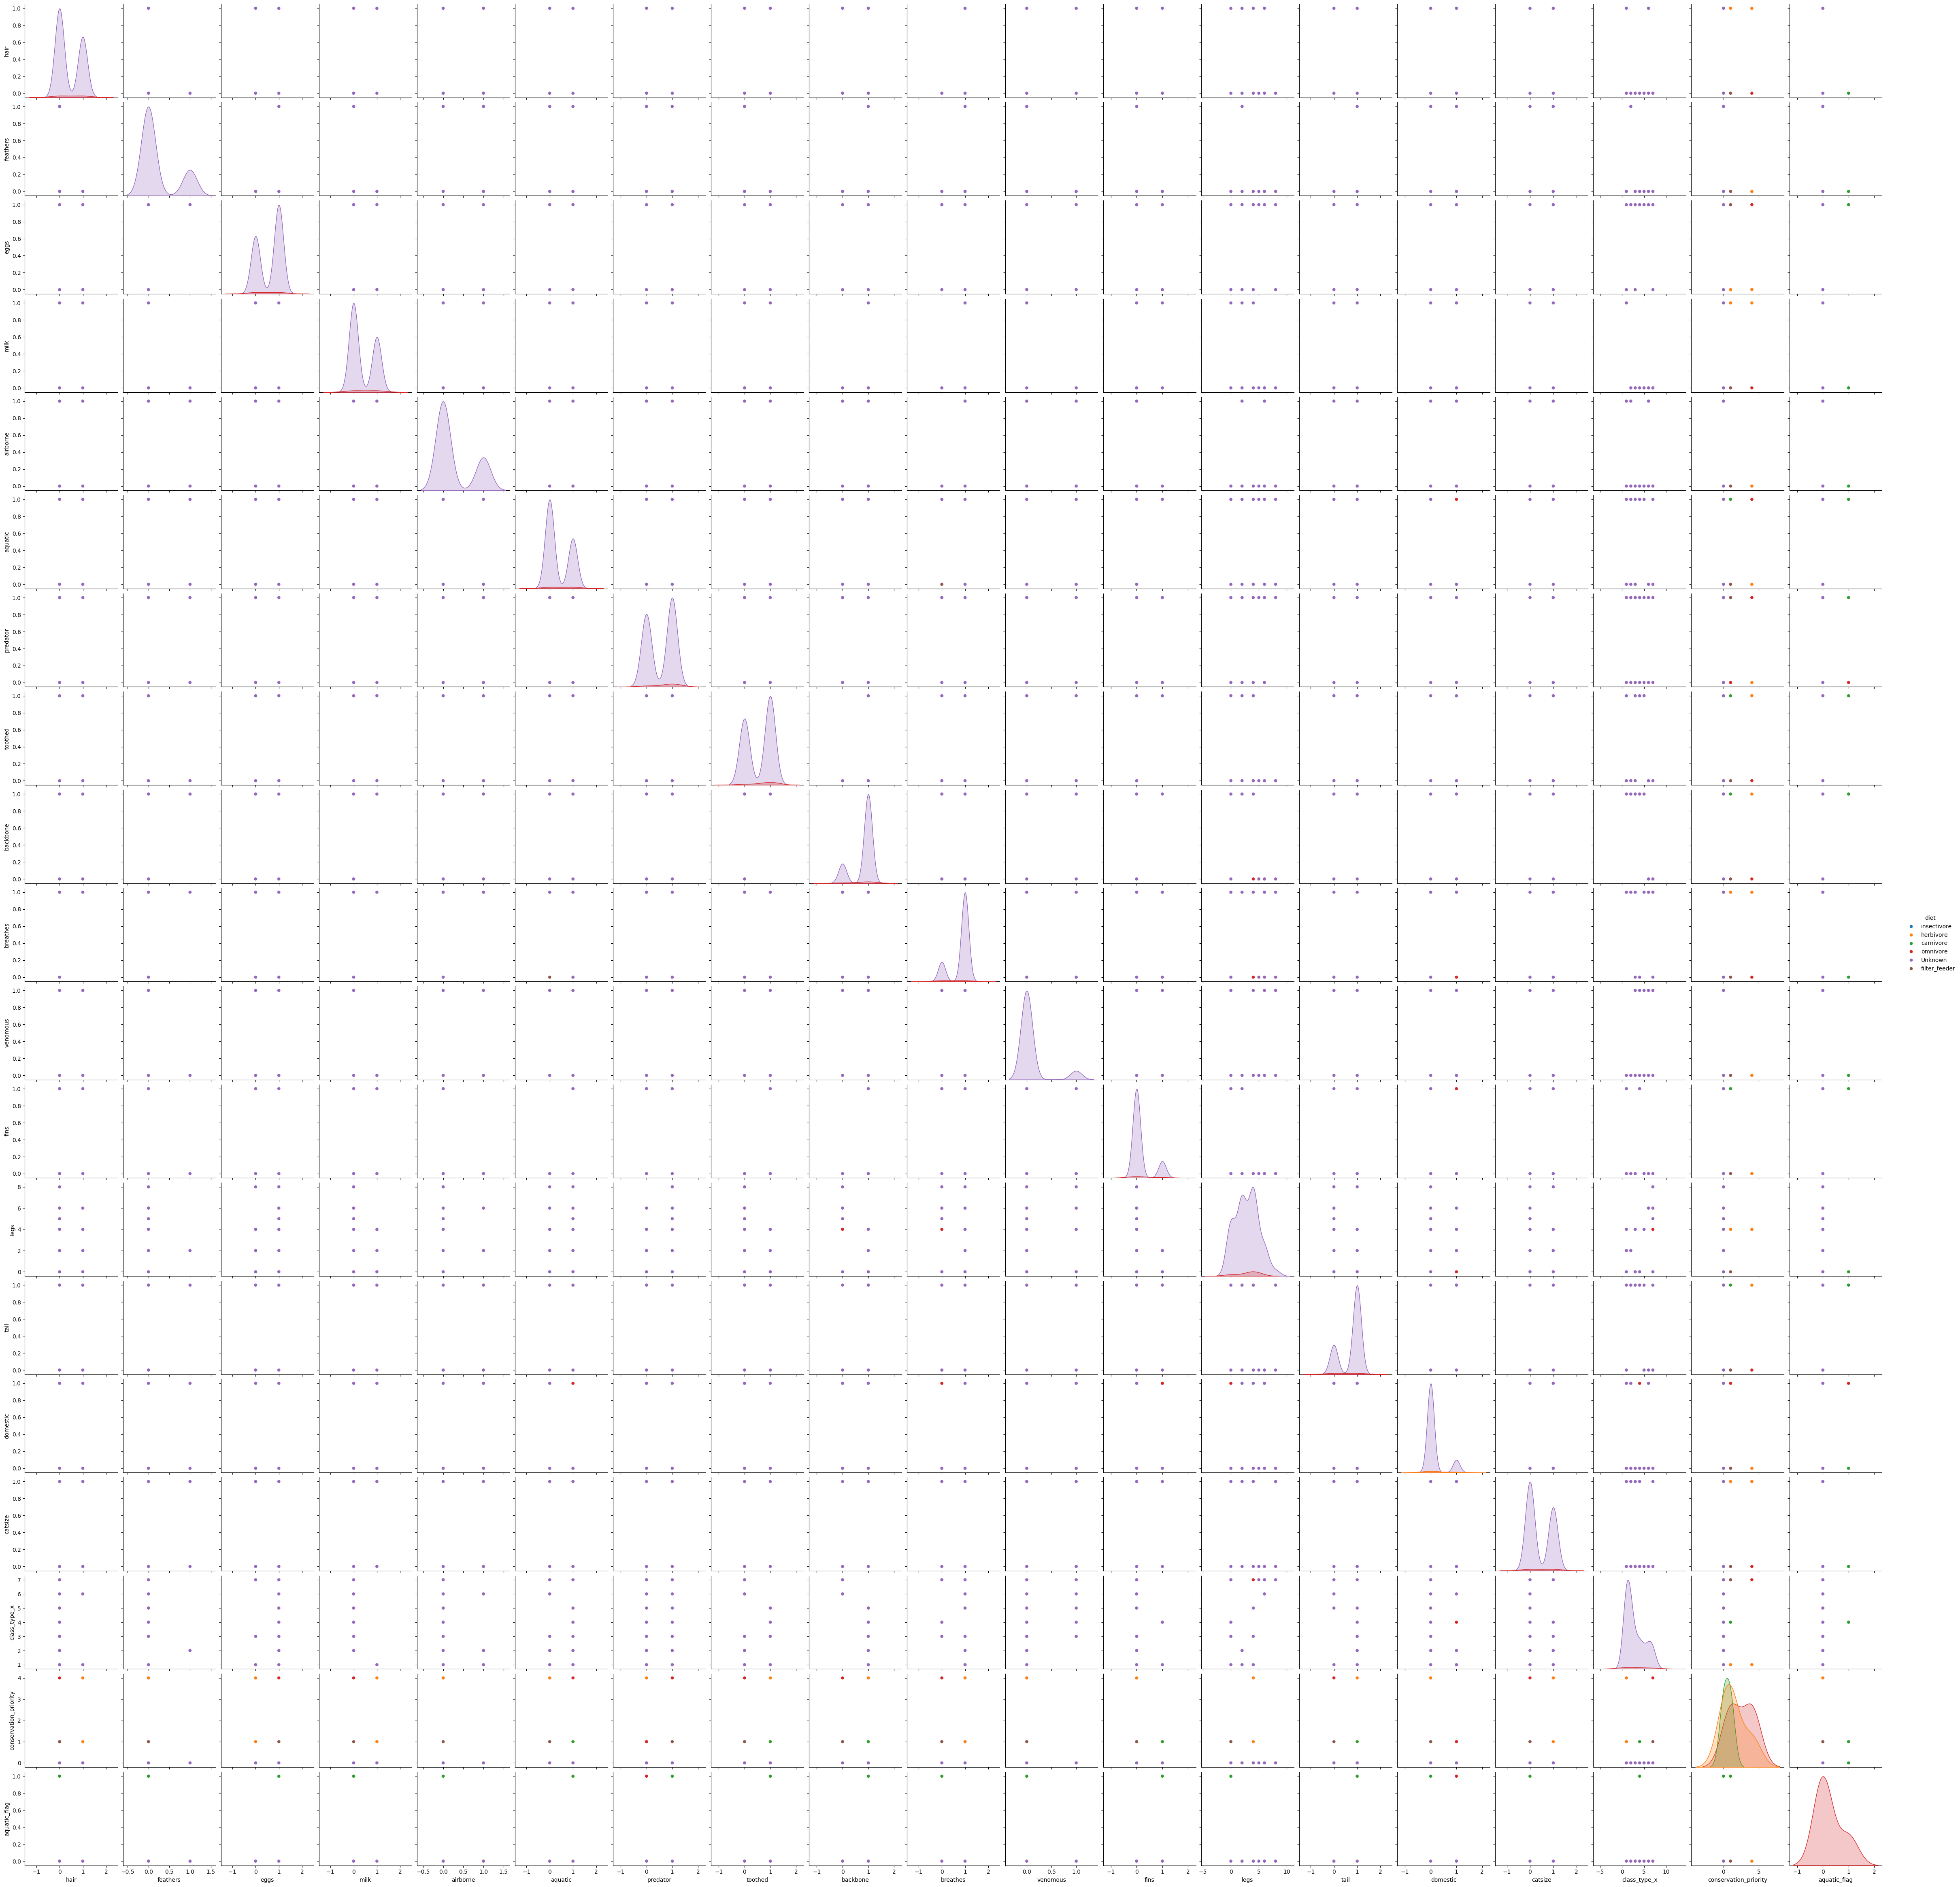

In [109]:
#3.scateerr plot matrix diet vs features
sns.pairplot(merge_df, hue="diet")
plt.show()


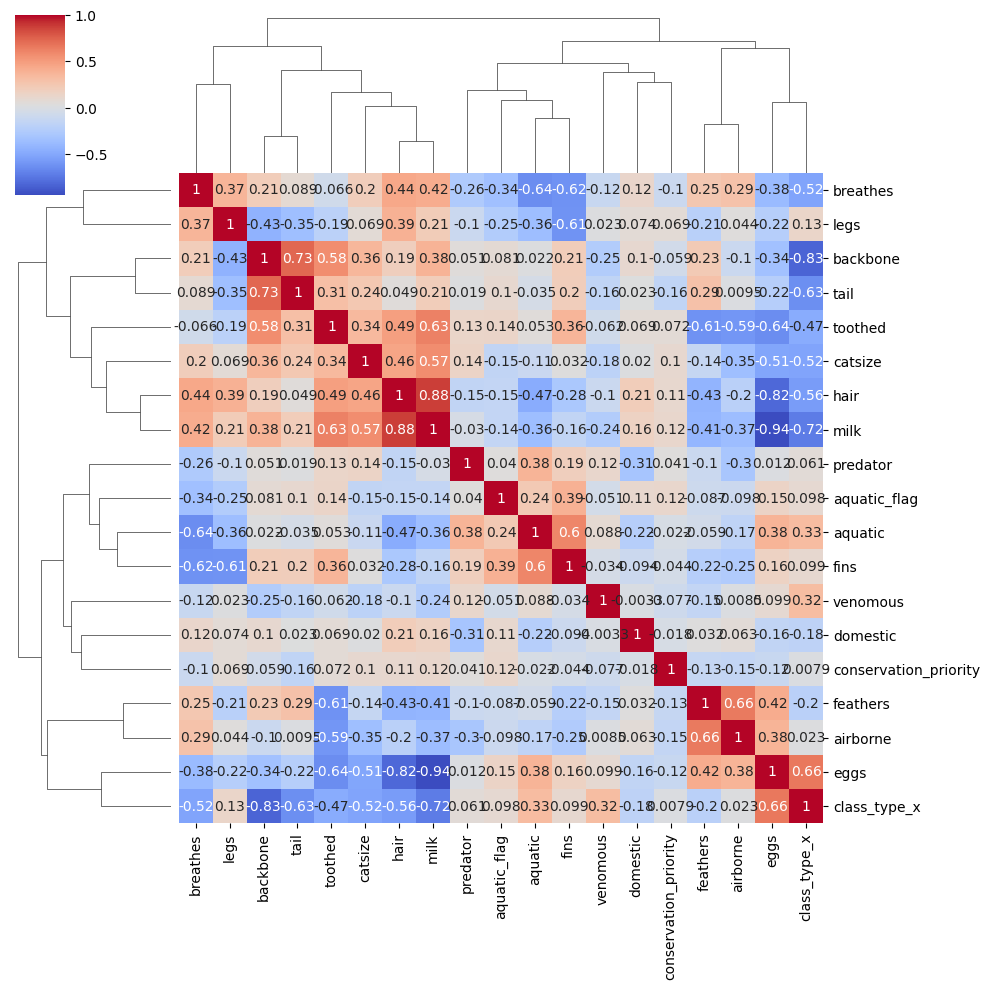

In [111]:
#4.correlation heat map with clustering
numeric_df = merge_df.select_dtypes(include=["int64", "float64"])
sns.clustermap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()


In [112]:
#TASK 3 MODEL TRAINING AND EVALUATION

In [126]:
#Dataset splitting
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = merge_df.select_dtypes(include=["int64", "float64"])
y = merge_df["class_type_x"]


#Train-test split (70/30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [127]:
#B. Configure and train random forset
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=3,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [115]:
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

In [116]:
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

overfitting_gap = train_accuracy - test_accuracy

In [128]:
#print traing performance
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("Overfitting Gap:", overfitting_gap)

Training Accuracy: 1.0
Testing Accuracy: 0.967741935483871
Overfitting Gap: 0.032258064516129004


Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         1
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00         3

    accuracy                           0.97        31
   macro avg       0.81      0.86      0.83        31
weighted avg       0.95      0.97      0.95        31



C:\Users\ub14-glab-007\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ub14-glab-007\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ub14-glab-007\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

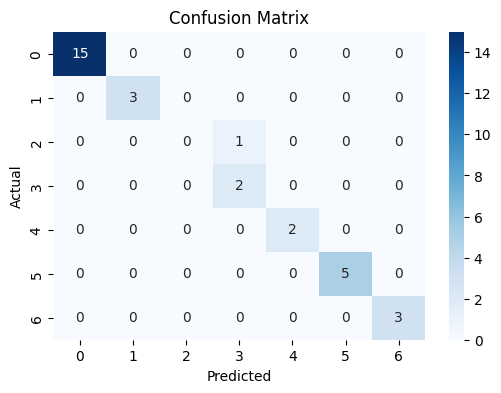

In [129]:
#Classificaton report
print("Classification Report:\n")
print(classification_report(y_test, test_pred))

# -------- CONFUSION MATRIX --------
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="g")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [131]:
#KNN Model Training & Comparison
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# -------------------------
# Train KNN model (k = 5)
# -------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# predictions
knn_train_pred = knn.predict(X_train)
knn_test_pred = knn.predict(X_test)

# accuracy scores
knn_train_acc = accuracy_score(y_train, knn_train_pred)
knn_test_acc = accuracy_score(y_test, knn_test_pred)

knn_gap = knn_train_acc - knn_test_acc

# -------------------------
# Print Comparison
# -------------------------
print("===== MODEL COMPARISON =====")
print("\nRandom Forest:")
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("Overfitting Gap:", overfitting_gap)

print("\nK-Nearest Neighbours (k=5):")
print("Training Accuracy:", knn_train_acc)
print("Testing Accuracy:", knn_test_acc)
print("Overfitting Gap:", knn_gap)




===== MODEL COMPARISON =====

Random Forest:
Training Accuracy: 1.0
Testing Accuracy: 0.967741935483871
Overfitting Gap: 0.032258064516129004

K-Nearest Neighbours (k=5):
Training Accuracy: 0.9285714285714286
Testing Accuracy: 0.9032258064516129
Overfitting Gap: 0.025345622119815725


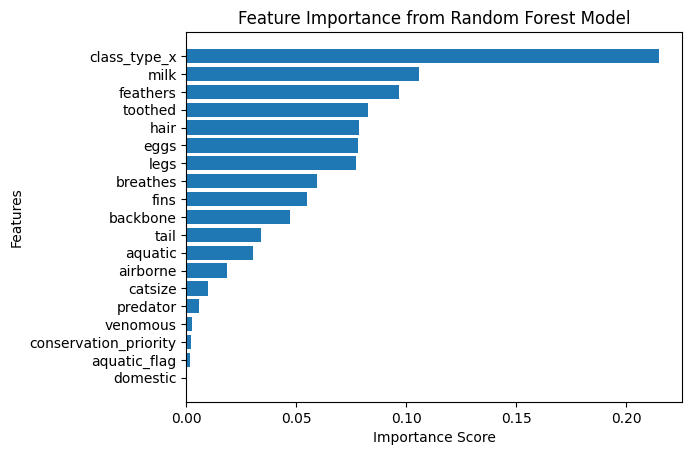

In [130]:
#feature importance
import matplotlib.pyplot as plt
import pandas as pd

# get feature importance values
importance = rf.feature_importances_

# create dataframe for sorting and plotting
feat_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values(by="importance", ascending=True)

# plot
plt.barh(feat_df["feature"], feat_df["importance"])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance from Random Forest Model")
plt.show()


In [132]:
#MOdel comparison 
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "KNN (k=5)"],
    "Train Accuracy": [train_accuracy, knn_train_acc],
    "Test Accuracy": [test_accuracy, knn_test_acc],
    "Overfitting Gap": [overfitting_gap, knn_gap]
})

comparison_df

,Model,Train Accuracy,Test Accuracy,Overfitting Gap
0,Random Forest,1.000000,0.967742,0.032258
1,KNN (k=5),0.928571,0.903226,0.025346
